In [1]:
import anndata as a
import pandas as pd
import scanpy as sc
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

In [2]:
mpl.rcParams["figure.figsize"] = (5, 5)
mpl.rcParams['pdf.fonttype'] = 42

In [3]:
adata = sc.read('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/ascites_case/ascites_malignant_cells_primary_and_first_timepoint.h5ad')
adata

AnnData object with n_obs × n_vars = 2478 × 17005
    obs: 'orig.ident', 'nCount_RNA', 'RNA_snn_res.0.7', 'seurat_clusters', 'cellcycle1', 'OC2', 'AC3', 'OPC_shared4', 'OPC_variable5'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_mnn', 'X_pca', 'X_umap'

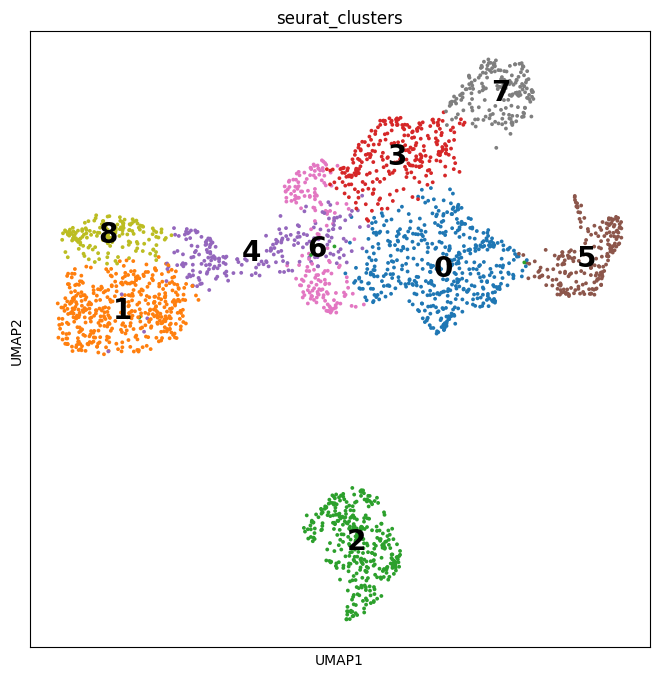

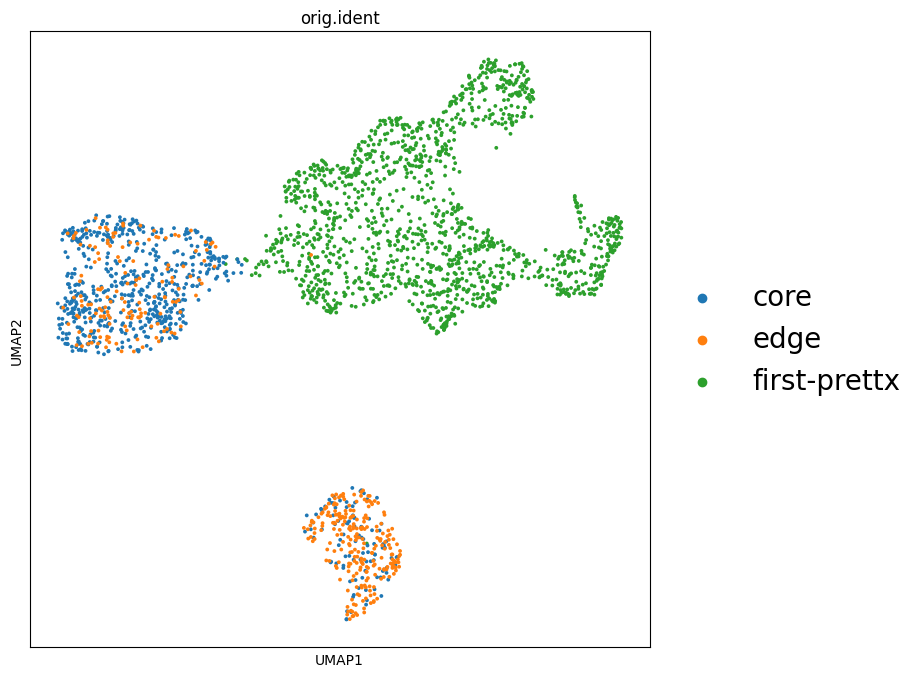

In [5]:
# show regions in UMAP coordinates
with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [8, 8]}):
    sc.pl.umap(adata, color=['seurat_clusters'], size=30,
               color_map = 'RdPu', ncols = 2, legend_loc='on data',
               legend_fontsize=20)
    # sc.pl.umap(adata, color=['ClusterName'], size=30,
    #            color_map = 'RdPu', ncols = 2,
    #            legend_fontsize=20)
    sc.pl.umap(adata, color=['orig.ident'], size=30,
               color_map = 'RdPu', ncols = 2,
               legend_fontsize=20)

In [7]:
sc.pp.neighbors(adata)
sc.tl.diffmap(adata)

/home/cruiz2/miniconda3/envs/r_env_standr/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
adata

AnnData object with n_obs × n_vars = 2478 × 17005
    obs: 'orig.ident', 'nCount_RNA', 'RNA_snn_res.0.7', 'seurat_clusters', 'cellcycle1', 'OC2', 'AC3', 'OPC_shared4', 'OPC_variable5'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'seurat_clusters_colors', 'orig.ident_colors', 'neighbors', 'diffmap_evals'
    obsm: 'X_mnn', 'X_pca', 'X_umap', 'X_diffmap'
    obsp: 'distances', 'connectivities'

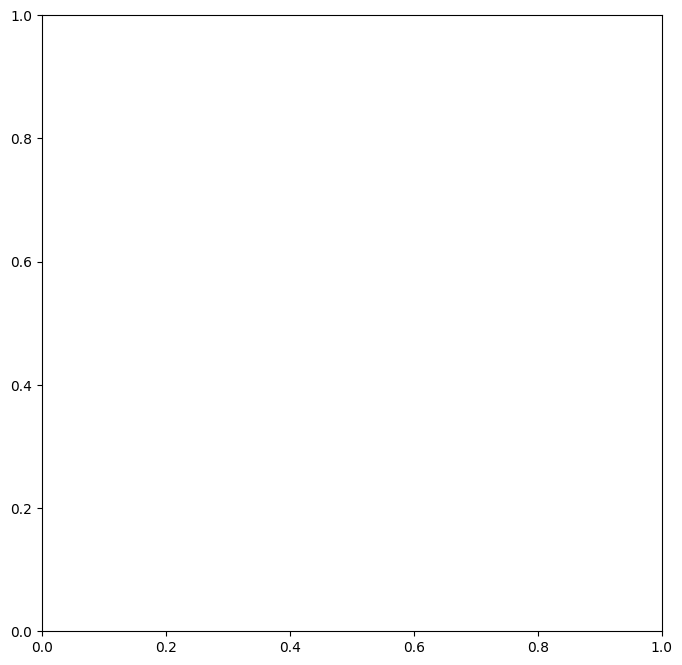

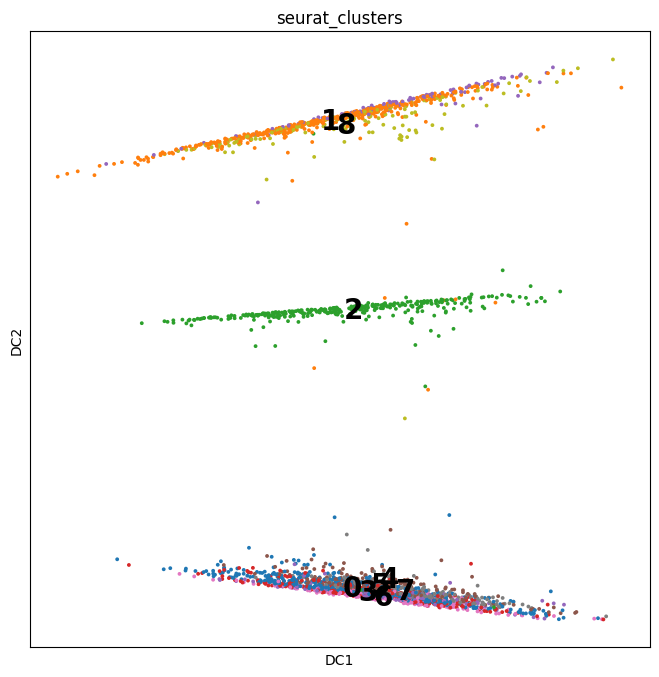

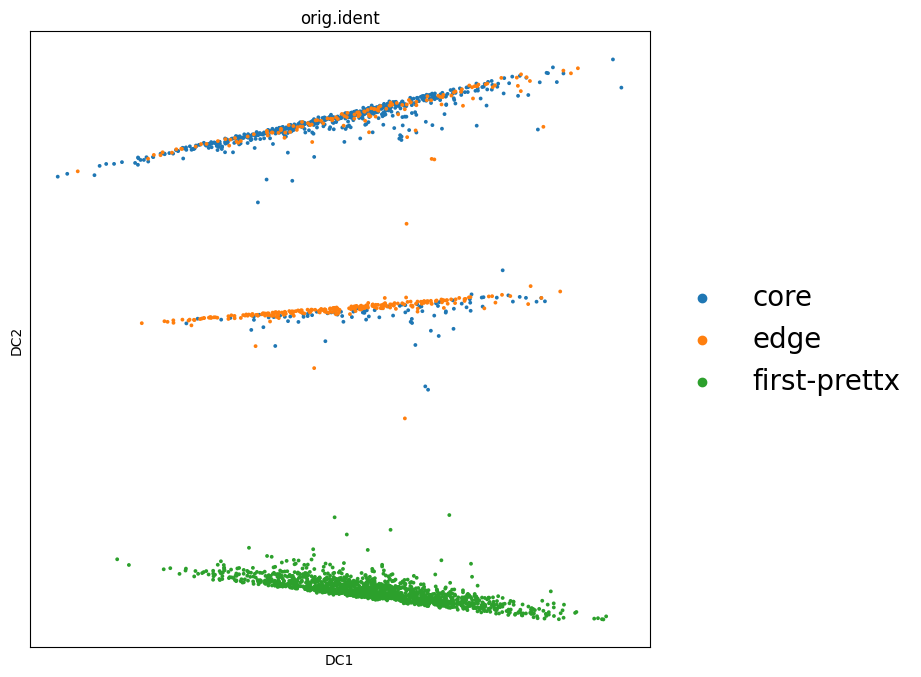

In [10]:
# show regions in UMAP coordinates
with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [8, 8]}):
    sc.pl.diffmap(adata, color=['seurat_clusters'], 
                  size=30,
                  legend_loc='on data',
               legend_fontsize=20)
    sc.pl.diffmap(adata, color=['orig.ident'], 
                  size=30,
               legend_fontsize=20)

In [11]:
print(adata.X)

  (0, 0)	0.5985086859734916
  (1, 0)	1.0438854337313728
  (2, 0)	1.4386606037852703
  (3, 0)	1.2881440174119532
  (4, 0)	1.092165211669755
  (5, 0)	0.44303647261614226
  (6, 0)	0.7740344449363625
  (7, 0)	1.6301438354417452
  (8, 0)	1.1006832360312908
  (9, 0)	1.359141248859849
  (10, 0)	1.1714216420130659
  (11, 0)	1.4716013230140574
  (12, 0)	1.142649639163501
  (13, 0)	1.7425657603399505
  (14, 0)	1.6864804398805737
  (15, 0)	0.7002044679627195
  (16, 0)	0.9969076219562292
  (17, 0)	0.819402185520548
  (18, 0)	0.6118730539604589
  (19, 0)	0.4876407249517076
  (20, 0)	0.6390153461607563
  (21, 0)	1.085941393456122
  (22, 0)	0.43122491457960654
  (23, 0)	0.6272162267838387
  (24, 0)	1.4153323762748728
  :	:
  (2363, 17004)	0.9812461107442206
  (2370, 17004)	0.9571884495019943
  (2373, 17004)	1.1402849850686776
  (2379, 17004)	0.9600638800261517
  (2389, 17004)	0.9469304216509485
  (2393, 17004)	0.9842798038176195
  (2396, 17004)	0.9655686612755973
  (2401, 17004)	1.610719142590149
  (

In [12]:
sc.external.tl.phate(adata)

/home/cruiz2/miniconda3/envs/r_env_standr/lib/python3.9/site-packages/phate/phate.py:186: FutureWarning: k is deprecated. Please use knn in future.
  warnings.warn("k is deprecated. Please use knn in future.", FutureWarning)
/home/cruiz2/miniconda3/envs/r_env_standr/lib/python3.9/site-packages/phate/phate.py:190: FutureWarning: a is deprecated. Please use decay in future.
  warnings.warn("a is deprecated. Please use decay in future.", FutureWarning)


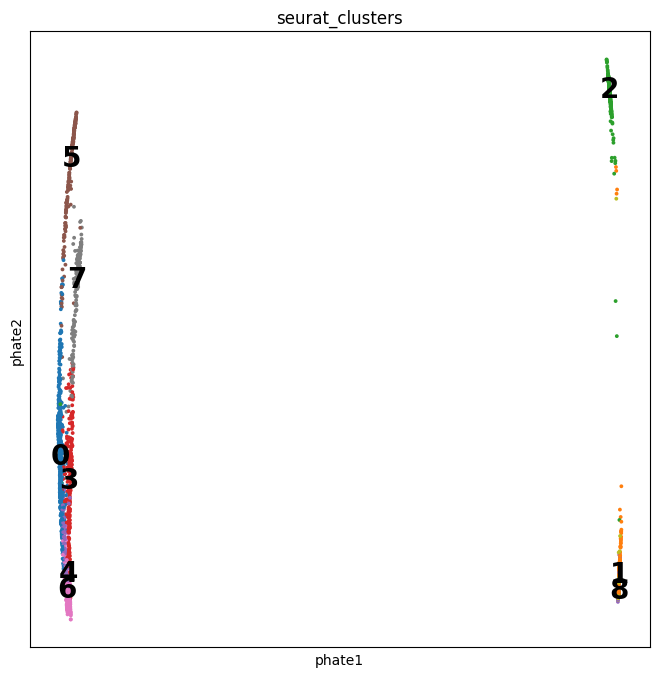

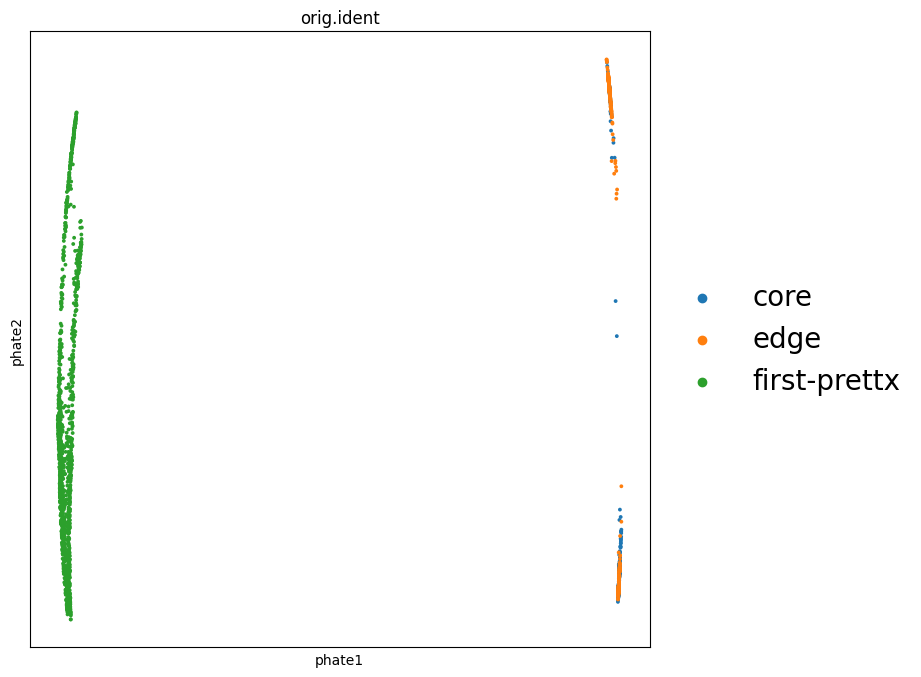

In [13]:
# show regions in UMAP coordinates
with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [8, 8]}):
    sc.external.pl.phate(adata, color=['seurat_clusters'], size=30,
               color_map = 'RdPu', legend_loc='on data',
               legend_fontsize=20)
    sc.external.pl.phate(adata, color=['orig.ident'], size=30,
               color_map = 'RdPu', 
               legend_fontsize=20)

In [14]:
import palantir

# warnings
import warnings
from numba.core.errors import NumbaDeprecationWarning

warnings.filterwarnings(action="ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings(
    action="ignore", module="scanpy", message="No data for colormapping"
)

In [15]:
dm_res = palantir.utils.run_diffusion_maps(adata, n_components=5)

In [16]:
ms_data = palantir.utils.determine_multiscale_space(adata)

In [17]:
imputed_X = palantir.utils.run_magic_imputation(adata)

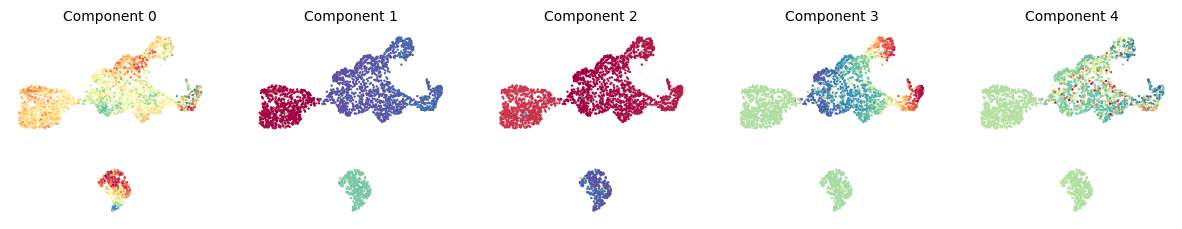

In [18]:
palantir.plot.plot_diffusion_components(adata)
plt.show()

In [21]:
adata.obs

,orig.ident,nCount_RNA,RNA_snn_res.0.7,seurat_clusters,cellcycle1,OC2,AC3,OPC_shared4,OPC_variable5
ascites_first-prettx_AAACCCATCTCGCTCA-1,first-prettx,50065.0,7,7,0.797909,-0.085806,0.252249,0.084266,0.016474
ascites_first-prettx_AAACCCATCTTCCACG-1,first-prettx,79998.0,0,0,0.120437,-0.090670,-0.069389,-0.020393,-0.023660
ascites_first-prettx_AAACGAACATAGGAGC-1,first-prettx,50540.0,3,3,-0.092535,0.096168,0.257936,-0.007453,0.115495
ascites_first-prettx_AAACGAAGTTCACGAT-1,first-prettx,33273.0,0,0,-0.019901,-0.034957,0.061876,0.134718,0.073670
ascites_first-prettx_AAACGAAGTTGATCGT-1,first-prettx,40803.0,6,6,-0.075347,-0.069377,0.085017,-0.044798,-0.195675
...,...,...,...,...,...,...,...,...,...
primary.tumor_edge_TTTCCTCCAGTTAGAA-1,edge,30465.0,2,2,-0.206054,0.232732,-0.271169,0.173507,0.848248
primary.tumor_edge_TTTCCTCGTGGTATGG-1,edge,30598.0,8,8,-0.225005,0.026149,0.554416,0.004261,0.220949
primary.tumor_edge_TTTCCTCTCCTATTGT-1,edge,30688.0,1,1,-0.191269,-0.012902,0.605914,-0.210418,0.312254
primary.tumor_edge_TTTGACTCACTTGAGT-1,edge,31492.0,2,2,-0.137740,0.261028,-0.318648,0.034026,0.900261


In [22]:
# Assuming 'adata' is your AnnData object
# List of clusters to sample from
clusters_of_interest = ['7','5','1']

# Initialize an empty dictionary to store results
random_obs_names = {}

# Iterate through each cluster and select a random observation name
for cluster in clusters_of_interest:
    # Subset the AnnData object for the current cluster
    cluster_cells = adata.obs[adata.obs['seurat_clusters'] == cluster]
    
    # Randomly select one obs_name
    if not cluster_cells.empty:
        random_obs_name = np.random.choice(cluster_cells.index, size=1, replace=False)[0]
        random_obs_names[cluster] = random_obs_name
    else:
        random_obs_names[cluster] = None  # Handle cases where no cells exist for the cluster

# Print or return the dictionary of random obs_names
print(random_obs_names)

{'7': 'ascites_first-prettx_TTGAGTGGTTAGTCGT-1', '5': 'ascites_first-prettx_AGGACTTTCTGTGCTC-1', '1': 'primary.tumor_edge_GATAGAAGTAATTAGG-1'}


In [23]:
terminal_states = pd.Series(
    ["CloneA", "CloneB"],
    index=["ascites_first-prettx_TTGAGTGGTTAGTCGT-1", "ascites_first-prettx_AGGACTTTCTGTGCTC-1"],
)

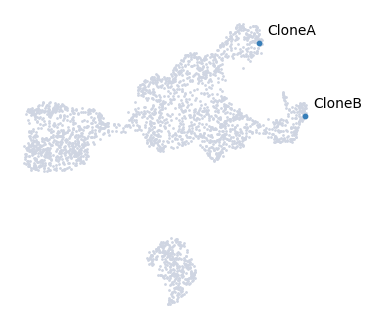

In [24]:
palantir.plot.highlight_cells_on_umap(adata, terminal_states)
plt.show()

In [25]:
start_cell = "primary.tumor_edge_GATAGAAGTAATTAGG-1"
pr_res = palantir.core.run_palantir(
    adata, start_cell, num_waypoints=500, terminal_states=terminal_states
)

Sampling and flocking waypoints...
Time for determining waypoints: 0.0022752086321512857 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.12223332722981771 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


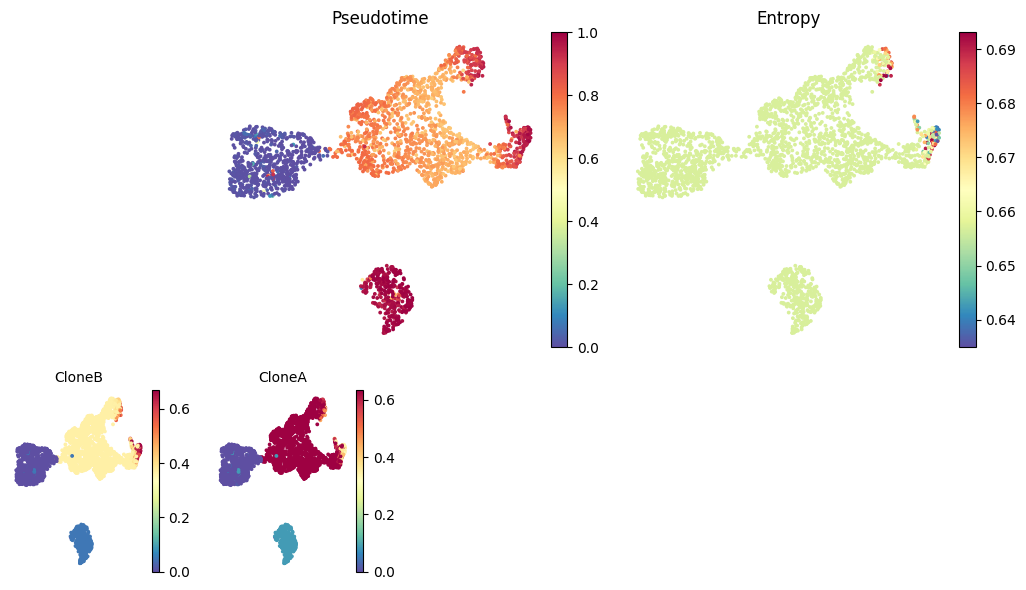

In [26]:
palantir.plot.plot_palantir_results(adata, s=3)
plt.show()

In [28]:
masks = palantir.presults.select_branch_cells(adata, q=.01, eps=.01)

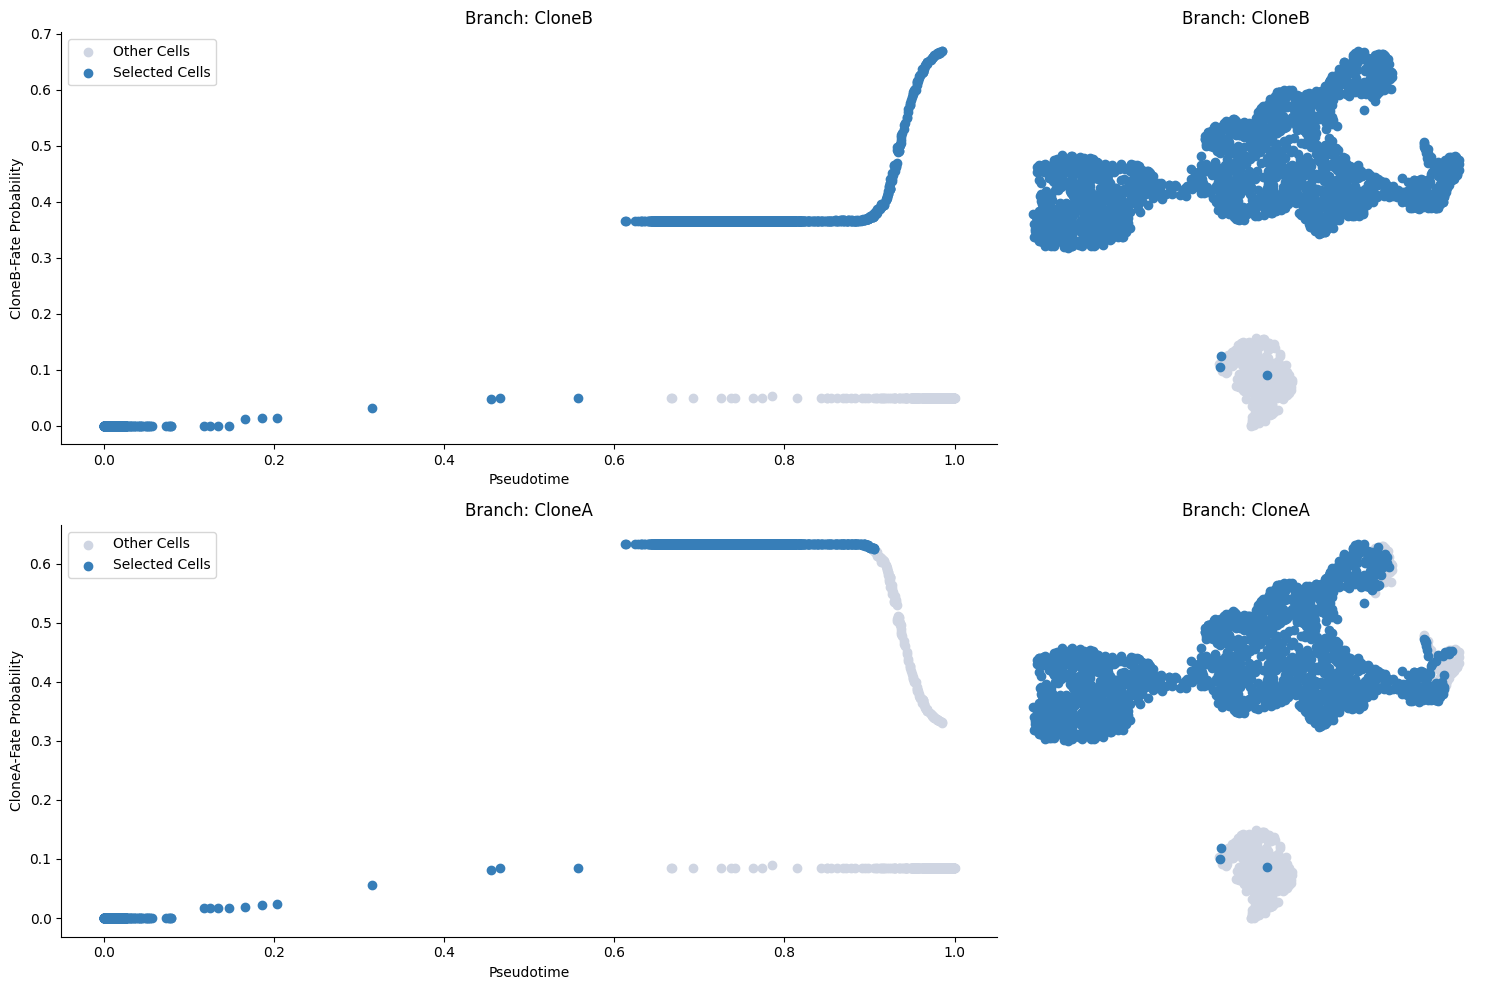

In [30]:
palantir.plot.plot_branch_selection(adata)
plt.show()

In [31]:
palantir.plot.plot_trajectory(adata, "CloneB")

[2024-12-06 20:50:55,876] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (2,136) and rank = 1.0.
[2024-12-06 20:50:55,877] [INFO    ] Using covariance function Matern52(ls=1.1299007373234566).
[2024-12-06 20:50:55,899] [INFO    ] Computing 50 landmarks with k-means clustering.


<Axes: title={'center': 'Branch: CloneB'}>

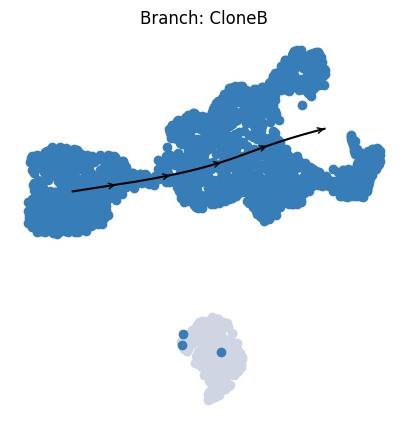

In [32]:
plt.show()

In [33]:
palantir.plot.plot_trajectory(
    adata,
    "CloneB",
    cell_color="palantir_entropy",
    n_arrows=10,
    color="red",
    scanpy_kwargs=dict(cmap="viridis"),
    arrowprops=dict(arrowstyle="-|>,head_length=.5,head_width=.5"),
)

[2024-12-06 20:51:53,872] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (2,136) and rank = 1.0.
[2024-12-06 20:51:53,874] [INFO    ] Using covariance function Matern52(ls=1.1299007373234566).
[2024-12-06 20:51:53,875] [INFO    ] Computing 50 landmarks with k-means clustering.


<Axes: title={'center': 'Branch: CloneB'}, xlabel='UMAP1', ylabel='UMAP2'>

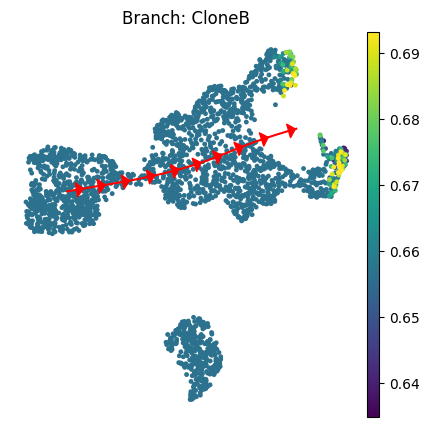

In [34]:
plt.show()

In [35]:
gene_trends = palantir.presults.compute_gene_trends(
    adata,
    expression_key="MAGIC_imputed_data",
)

CloneB
[2024-12-06 20:52:18,715] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (2,136) and rank = 1.0.
[2024-12-06 20:52:18,716] [INFO    ] Using covariance function Matern52(ls=1.0).
CloneA
[2024-12-06 20:52:21,043] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (2,009) and rank = 1.0.
[2024-12-06 20:52:21,044] [INFO    ] Using covariance function Matern52(ls=1.0).


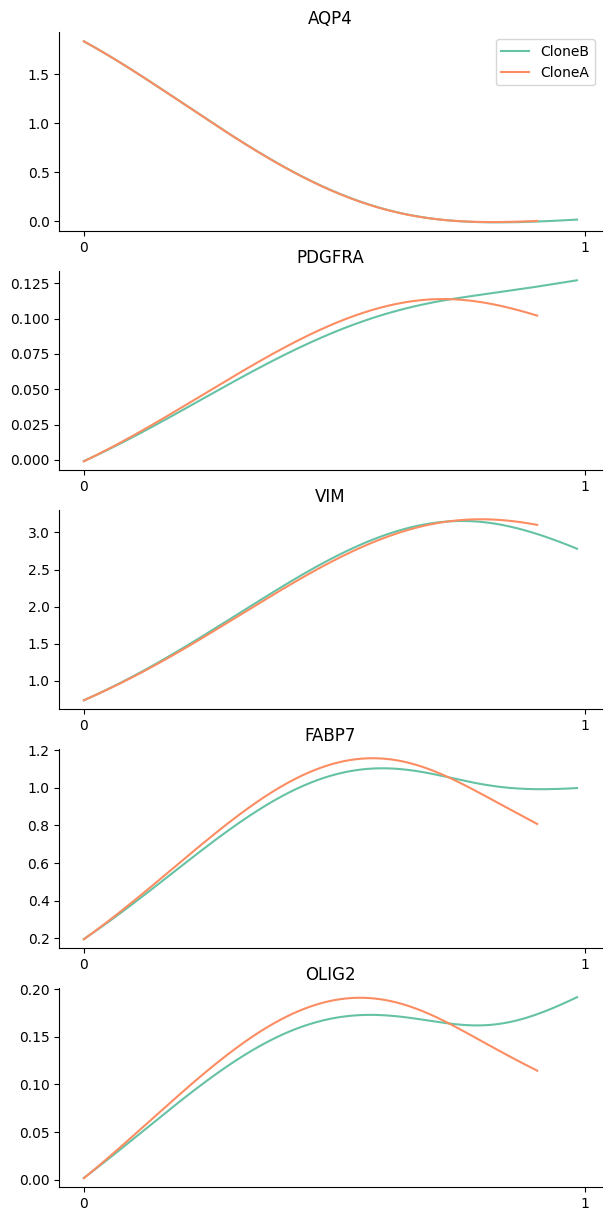

In [37]:
genes = ["AQP4", "PDGFRA", "VIM", "FABP7", 'OLIG2']
palantir.plot.plot_gene_trends(adata, genes)
plt.show()

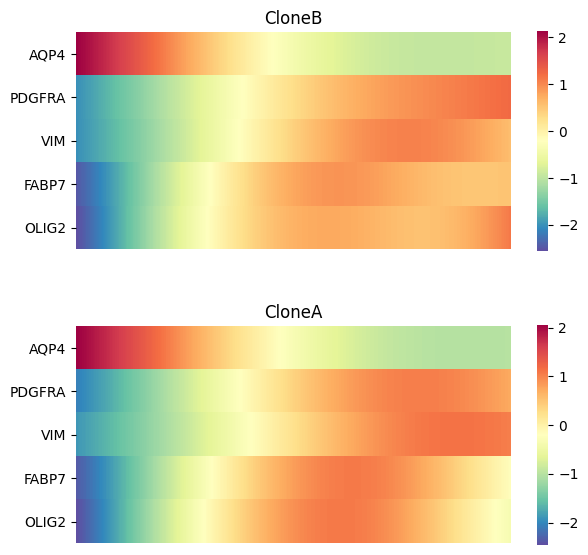

In [38]:
palantir.plot.plot_gene_trend_heatmaps(adata, genes)
plt.show()